# Pruning and Quantization in Keras using TrashNet Dataset
Deep learning models often contain a large number of parameters, which can lead to high memory and computation requirements. Pruning and quantization are techniques used to reduce the size of these models by removing unnecessary parameters and reducing precision, respectively, thus improving their efficiency without significantly impacting performance. In this example, we'll explore how to implement pruning and quantization in Keras using the TrashNet dataset, which contains images of various waste types.

## Understanding Pruning and Quantization
* Pruning involves identifying and removing connections (weights) in a neural network that contribute little to the network's performance. This reduces the number of parameters in the model, leading to a more efficient network.
* Quantization reduces the precision of weights and activations in the network, typically from 32-bit floating point numbers to lower bit-width integers. This reduces the memory and computation requirements of the model.

## TrashNet Dataset
The [TrashNet](https://github.com/garythung/trashnet) dataset contains images of six different waste types: cardboard, glass, metal, paper, plastic, and trash. Each image is labeled with its corresponding waste type, making it suitable for classification tasks. We will use this dataset to train a convolutional neural network (CNN) and then apply pruning and quantization to reduce its size.

### Summary

In this tutorial, you will:

1.   Train a `keras` model for TrashNet from scratch.
2.   Fine tune the model by applying the pruning API and see the accuracy.
3.   Create 3x smaller TF and TFLite models from pruning.
4.   Create a 10x smaller TFLite model from combining pruning and post-training quantization.
5.   See the persistence of accuracy from TF to TFLite.

## Setup
At first,we are going to install [tensorflow-model-optimization](https://www.tensorflow.org/model_optimization/guide/install). It provides a set of tools and techniques for optimizing and compressing deep learning models, including pruning, quantization, and weight clustering. These techniques can help reduce model size, improve inference speed, and reduce resource consumption, making them valuable for deploying models in resource-constrained environments.

In [1]:
! pip install -q tensorflow-model-optimization


In [2]:
pip install imutils # Provides a set of helper functions on top of OpenCV for easier image processing.

  Preparing metadata (setup.py) ... - \ done
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25834 sha256=27ea78dca46f6395bf0495b4dad94dadfcc8bfaa7c234ce9f216618d60ec79d6
  Stored in directory: /root/.cache/pip/wheels/85/cf/3a/e265e975a1e7c7e54eb3692d6aa4e2e7d6a3945d29da46f2d7
Successfully built imutils
Note: you may need to restart the kernel to use updated packages.


Import other libaries required to perform the operations

In [3]:
import tempfile  # Library for creating temporary files and directories
import os  # Operating system library for interacting with the file system
import tensorflow_hub as hub  # TensorFlow Hub for reusing pre-trained models
import tensorflow as tf  # TensorFlow library
import numpy as np  # NumPy library for numerical computations
import zipfile as zf  # Library for working with zip files

from tensorflow_model_optimization.python.core.keras.compat import keras  # TensorFlow Model Optimization toolkit for Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Image data generator for data augmentation
from sklearn.model_selection import train_test_split  # Library for splitting data into training and testing sets
import random  # Library for generating random numbers
import shutil  # Library for file operations
from keras.applications.mobilenet import decode_predictions, preprocess_input  # MobileNet model utilities

import pandas as pd  # Pandas library for data manipulation and analysis
import matplotlib.pyplot as plt  # Matplotlib library for plotting
from keras.layers import Flatten, Dense, GlobalAveragePooling2D, Dropout, Input  # Keras layers for building neural networks
from keras.applications import MobileNet  # MobileNet model
from keras.preprocessing import image  # Image preprocessing utilities
from keras.models import Model  # Keras Model class for defining neural network models
from keras.optimizers import Adam  # Adam optimizer for training neural networks
from sklearn.metrics import classification_report  # Classification report for model evaluation
from tensorflow_model_optimization.python.core.sparsity.keras.pruning_wrapper import PruneLowMagnitude  # Pruning wrapper for Keras models
import tensorflow_model_optimization as tfmot  # TensorFlow Model Optimization toolkit
import cv2  # OpenCV library for computer vision tasks
import imutils # library for image processing utilities 


2024-09-20 12:12:07.458220: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-20 12:12:07.458341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-20 12:12:07.595153: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Dataset pre-processing
We organize the TrashNet dataset into training, testing, and validation sets by creating a new directory structure. We then use the ImageDataGenerator class to load and preprocess the dataset, preparing it for training a deep learning model.

In [4]:
# Original dataset path
dataset_path = '/kaggle/input/trashnet/dataset-resized'

# New dataset path
output_path = '/kaggle/output'

# Create directories for train, test, and validation sets
os.makedirs(os.path.join(output_path, 'train'), exist_ok=True)
os.makedirs(os.path.join(output_path, 'test'), exist_ok=True)
os.makedirs(os.path.join(output_path, 'validation'), exist_ok=True)

# Get list of all subdirectories (classes) in the dataset
classes = os.listdir(dataset_path)

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    
    # Create directories for train, test, and validation sets for each class
    os.makedirs(os.path.join(output_path, 'train', class_name), exist_ok=True)
    os.makedirs(os.path.join(output_path, 'test', class_name), exist_ok=True)
    os.makedirs(os.path.join(output_path, 'validation', class_name), exist_ok=True)
    
    # Split the dataset into train, test, and validation sets for each class
    train_images, test_val_images = train_test_split(os.listdir(class_path), test_size=0.3, random_state=42)
    test_images, validation_images = train_test_split(test_val_images, test_size=0.5, random_state=42)

    # Copy images to train, test, and validation folders for each class
    for image in train_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(output_path, 'train', class_name, image))

    for image in test_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(output_path, 'test', class_name, image))

    for image in validation_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(output_path, 'validation', class_name, image))

# Define the image size and batch size
image_size = (224, 224)
batch_size = 16

# Use ImageDataGenerator to load and preprocess the dataset
datagen = ImageDataGenerator(
    rescale=1./255
)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    fill_mode='nearest',
    horizontal_flip=True,
    shear_range=0.2,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create generators for training, validation, and testing sets
train_generator = train_datagen.flow_from_directory(
    os.path.join(output_path, 'train'),
    target_size=image_size,
    batch_size=batch_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    os.path.join(output_path, 'validation'),
    target_size=image_size,
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='sparse',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(output_path, 'test'),
    target_size=image_size,
    batch_size=batch_size,
    class_mode="sparse",
    color_mode='rgb',
    shuffle=False
)

# Get the total number of images in the train, test, and validation sets
total_train = sum(len(files) for _, _, files in os.walk(os.path.join(output_path, 'train')))
total_test = sum(len(files) for _, _, files in os.walk(os.path.join(output_path, 'test')))
total_val = sum(len(files) for _, _, files in os.walk(os.path.join(output_path, 'validation')))

print("Total Train:", total_train)
print("Total Test:", total_test)
print("Total Validation:", total_val)


Found 1766 images belonging to 6 classes.
Found 383 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Total Train: 1766
Total Test: 378
Total Validation: 383


# Model Creation
We created a deep learning model for image classification using the [MobileNet](https://keras.io/api/applications/mobilenet/) architecture. We start by loading the pre-trained MobileNet model with ImageNet weights and remove the top classification layers. Then, we define custom layers for flattening and dense (fully connected) operations. Finally, we construct a sequential model by stacking the base MobileNet model with the custom layers, ending with a softmax activation for multi-class classification.

In [5]:
# Create the base MobileNet model with pre-trained weights
base_model = keras.applications.MobileNet(weights='imagenet', include_top=False, input_shape=image_size + (3,))

# Create the sequential model with the base MobileNet model,  Flatten layer, and Dense layer
model = keras.Sequential([
  base_model,
  keras.layers.Flatten(),
  keras.layers.Dense(6, activation='softmax')
])


17225924/17225924 [==============================] - 2s 0us/step


## Model Training and Evaluation
Here, we define an Adam optimizer with a specific learning rate and compile a deep learning model for image classification. The model is compiled with the Adam optimizer, a sparse categorical crossentropy loss function, and accuracy as the metric to monitor during training. We then train the model using the training data generated by train_generator and validate it using the validation data generated by validation_generator. The training process is run for 30 epochs, with a specific number of steps per epoch determined by the total number of images in the training and validation sets divided by the batch size.

In [6]:
# Define the optimizer with a specific learning rate
opt = Adam(learning_rate=1e-5)

# Compile the model with the optimizer, loss function, and metrics
model.compile(optimizer="adam",
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Train the model using the training generator, validate on the validation generator
# Use a specific number of epochs and steps per epoch
H = model.fit(train_generator, 
              epochs=30, 
              validation_data=validation_generator, 
              steps_per_epoch=total_train // batch_size,
              validation_steps=total_val // batch_size,)

Epoch 1/30


I0000 00:00:1726834389.928679     110 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 [==============================] - 69s 215ms/step - loss: 6.8736 - accuracy: 0.5227 - val_loss: 43.7054 - val_accuracy: 0.2554
Epoch 2/30
110/110 [==============================] - 21s 180ms/step - loss: 1.4033 - accuracy: 0.6480 - val_loss: 3.5860 - val_accuracy: 0.7310
Epoch 3/30
110/110 [==============================] - 20s 183ms/step - loss: 0.9274 - accuracy: 0.7320 - val_loss: 0.8392 - val_accuracy: 0.8179
Epoch 4/30
110/110 [==============================] - 20s 180ms/step - loss: 0.7584 - accuracy: 0.7766 - val_loss: 1.1624 - val_accuracy: 0.7473
Epoch 5/30
110/110 [==============================] - 19s 175ms/step - loss: 0.7128 - accuracy: 0.7937 - val_loss: 1.1592 - val_accuracy: 0.8125
Epoch 6/30
110/110 [==============================] - 20s 179ms/step - loss: 0.7671 - accuracy: 0.7834 - val_loss: 0.6439 - val_accuracy: 0.8478
Epoch 7/30
110/110 [==============================] - 19s 178ms/step - loss: 0.5765 - accuracy: 0.8211 - val_loss: 0.7132 - val_accuracy: 0.

Let's plot the accuracy and loss that happened during our training along with our model.

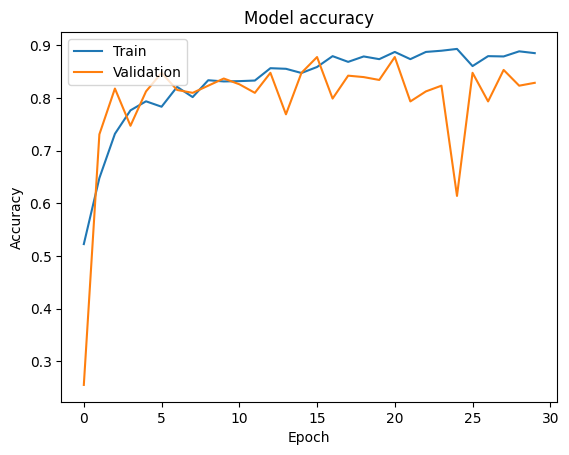

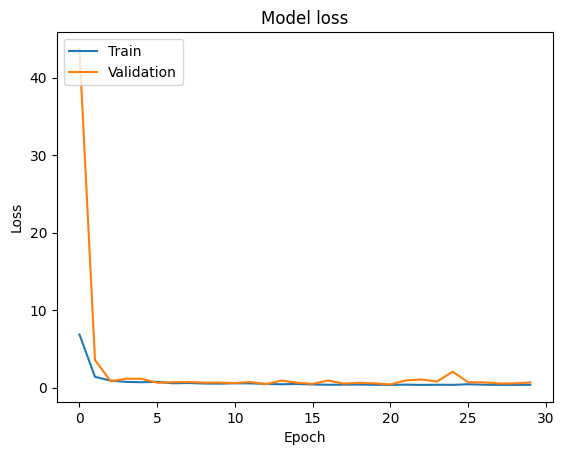

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenet_1.00_224 (Functi  (None, 7, 7, 1024)        3228864   
 onal)                                                           
                                                                 
 flatten (Flatten)           (None, 50176)             0         
                                                                 
 dense (Dense)               (None, 6)                 301062    
                                                                 
Total params: 3529926 (13.47 MB)
Trainable params: 3508038 (13.38 MB)
Non-trainable params: 21888 (85.50 KB)
_________________________________________________________________


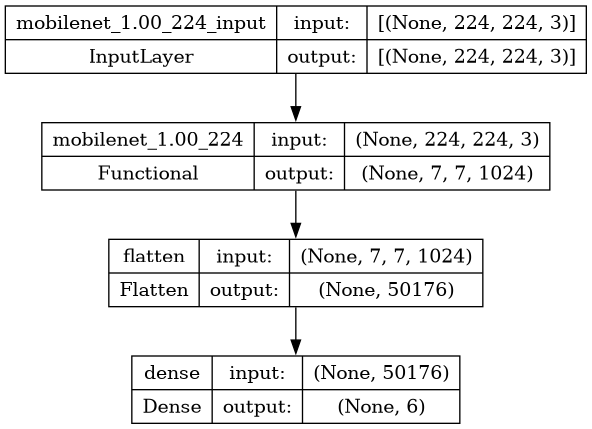

In [7]:
# Plot training & validation accuracy values
plt.plot(H.history['accuracy'])
plt.plot(H.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(H.history['loss'])
plt.plot(H.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Display a summary of the model architecture, including the number of parameters and output shapes
model.summary()

# Plot the model architecture graphically, showing the shapes of input and output tensors
keras.utils.plot_model(model, show_shapes=True)


Let's evaluate the accuracy of the pruned model on the test set to establish a baseline accuracy. We then save the pruned Keras model to a temporary file without including the optimizer configuration. This step is important for further optimization or deployment of the pruned model.

In [8]:
# Evaluate the baseline model's accuracy on the test set
_, baseline_model_accuracy = model.evaluate(test_generator,
                                            steps=(total_test // batch_size) + 1, verbose=0)

# Print the baseline test accuracy
print('Baseline test accuracy:', baseline_model_accuracy)

# Save the pruned Keras model to a temporary file
_, keras_file = tempfile.mkstemp('.h5')
keras.models.save_model(model, keras_file, include_optimizer=False)
print('Saved pruned Keras model to:', keras_file)

Baseline test accuracy: 0.8439153432846069
Saved pruned Keras model to: /tmp/tmpzm4zfsst.h5


/tmp/ipykernel_26/161867575.py:10: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(model, keras_file, include_optimizer=False)


# Fine-tune pre-trained model with pruning
Fine-tuning a pre-trained model with pruning involves loading a pre-trained model, applying pruning to reduce its size and potentially improve efficiency, compiling the pruned model with appropriate settings, fine-tuning the model on a specific dataset, often with a smaller learning rate, evaluating its performance, and finally saving the fine-tuned model for future use or deployment.

## Define the model
Here, we apply magnitude-based weight pruning to the model using TensorFlow Model Optimization. We define a pruning schedule that gradually increases the sparsity of the model's weights from 50% to 90% over 2000 steps. After pruning, we compile the pruned model with the Adam optimizer, sparse categorical crossentropy loss function, and accuracy metric. Finally, we display a summary of the pruned model's architecture to observe the changes in the number of parameters and layers due to pruning.

In [9]:
# Define the pruning parameters, including the pruning schedule
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude
pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.50,
        final_sparsity=0.90,
        begin_step=0,
        end_step=2000)
}

# Apply pruning to the model
model_for_pruning = prune_low_magnitude(model, **pruning_params)

# Compile the pruned model with the Adam optimizer, sparse categorical crossentropy loss, and accuracy metric
model_for_pruning.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Display a summary of the pruned model's architecture
model_for_pruning.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenet_1.00_224 (Functi  (None, 7, 7, 1024)        6369411   
 onal)                                                           
                                                                 
 prune_low_magnitude_flatte  (None, 50176)             1         
 n (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense   (None, 6)                 602120    
 (PruneLowMagnitude)                                             
                                                                 
Total params: 6971532 (26.59 MB)
Trainable params: 3508038 (13.38 MB)
Non-trainable params: 3463494 (13.21 MB)
_________________________________________________________________


### Train and evaluate the model against baseline

We create a temporary directory to store logging information. We define callbacks for pruning, including updating the pruning step and logging summaries. Then, we fit the model with pruning using these callbacks to further optimize its performance. The model_for_pruning is the model that has been pruned and is being fine-tuned on the dataset. The train_generator and validation_generator are used to feed batches of images to the model during training and validation, respectively.

In [10]:
# Create a temporary directory to store logs
logdir = tempfile.mkdtemp()

# Define callbacks for pruning, including updating the pruning step and logging summaries
callbacks = [
  tfmot.sparsity.keras.UpdatePruningStep(),
  tfmot.sparsity.keras.PruningSummaries(log_dir=logdir),
]

# Fit the model with pruning to further optimize its performance
model_for_pruning.fit(train_generator, 
                      epochs=30, 
                      validation_data=validation_generator, 
                      steps_per_epoch=total_train // batch_size,
                      validation_steps=total_val // batch_size,
                      callbacks=callbacks)

Epoch 1/30


/opt/conda/lib/python3.10/site-packages/tf_keras/src/backend.py:5729: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


110/110 [==============================] - 71s 278ms/step - loss: 0.5371 - accuracy: 0.8349 - val_loss: 1.0646 - val_accuracy: 0.6386
Epoch 2/30
110/110 [==============================] - 20s 181ms/step - loss: 0.3718 - accuracy: 0.8794 - val_loss: 0.9655 - val_accuracy: 0.6413
Epoch 3/30
110/110 [==============================] - 20s 184ms/step - loss: 0.3902 - accuracy: 0.8817 - val_loss: 0.7871 - val_accuracy: 0.7147
Epoch 4/30
110/110 [==============================] - 20s 183ms/step - loss: 0.3217 - accuracy: 0.8971 - val_loss: 0.6955 - val_accuracy: 0.7582
Epoch 5/30
110/110 [==============================] - 20s 184ms/step - loss: 0.3240 - accuracy: 0.8994 - val_loss: 0.6692 - val_accuracy: 0.7609
Epoch 6/30
110/110 [==============================] - 20s 178ms/step - loss: 0.3571 - accuracy: 0.8977 - val_loss: 0.9952 - val_accuracy: 0.6766
Epoch 7/30
110/110 [==============================] - 20s 185ms/step - loss: 0.3133 - accuracy: 0.8977 - val_loss: 0.6131 - val_accuracy: 0.7

We compare the total number of parameters in the original model model with the pruned model model_for_pruning, displaying the counts before and after pruning. We then reset the test generator and evaluate the pruned model on the test set to determine its accuracy.

In [11]:
# Display the total number of parameters before and after pruning
print("Total params before pruning:", model.count_params())
print("Total params after pruning:", model_for_pruning.count_params())

# Reset the test generator and evaluate the pruned model on the test set
test_generator.reset()
_, model_for_pruning_accuracy = model_for_pruning.evaluate(test_generator,
                                 steps=(total_test // batch_size) + 1, verbose=0)
print('Pruned test accuracy:', model_for_pruning_accuracy)



Total params before pruning: 3529926
Total params after pruning: 6971532
Pruned test accuracy: 0.8809523582458496


# Create 3x smaller models from pruning

We are going to perform a series of actions to compress a pruned Keras model using TensorFlow Model Optimization (tfmot) and standard compression algorithms. First, we will strip the pruning-related variables from the pruned model and save it as a Keras model file.

In [12]:
# Strip pruning from the pruned model for export
model_for_export = tfmot.sparsity.keras.strip_pruning(model_for_pruning)

# Save the pruned Keras model to a temporary file without including the optimizer
_, pruned_keras_file = tempfile.mkstemp('.h5')
keras.models.save_model(model_for_export, pruned_keras_file, include_optimizer=False)
print('Saved pruned Keras model to:', pruned_keras_file)

Saved pruned Keras model to: /tmp/tmpiwxf0iea.h5


/tmp/ipykernel_26/2939057242.py:6: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(model_for_export, pruned_keras_file, include_optimizer=False)


 Next, we will convert this pruned Keras model into a TensorFlow Lite (TFLite) model, which is more suitable for deployment on resource-constrained devices. After converting, we will save the pruned TFLite model as a file. 

In [13]:
# Convert the pruned Keras model to a TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
pruned_tflite_model = converter.convert()

# Save the pruned TensorFlow Lite model to a temporary file
_, pruned_tflite_file = tempfile.mkstemp('.tflite')
with open(pruned_tflite_file, 'wb') as f:
  f.write(pruned_tflite_model)

# Print the path to the saved pruned TFLite model
print('Saved pruned TFLite model to:', pruned_tflite_file)


Summary on the non-converted ops:
---------------------------------
 * Accepted dialects: tfl, builtin, func
 * Non-Converted Ops: 58, Total Ops 95, % non-converted = 61.05 %
 * 58 ARITH ops

- arith.constant:   58 occurrences  (f32: 56, i32: 2)



  (f32: 14)
  (f32: 13)
  (f32: 1)
  (f32: 4)
  (f32: 1)
  (f32: 1)


Saved pruned TFLite model to: /tmp/tmpjm6bep3p.tflite


After converting, we save the pruned TFLite model to another temporary file. Finally, we define a helper function get_gzipped_model_size to measure the size of the gzipped model files.

In [14]:
def get_gzipped_model_size(file):
  # Returns size of gzipped model, in bytes.
  import os
  import zipfile

  _, zipped_file = tempfile.mkstemp('.zip')
  with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
    f.write(file)

  return os.path.getsize(zipped_file)

By comparing the sizes of the gzipped baseline Keras model, gzipped pruned Keras model, and gzipped pruned TFLite model, we observe a significant reduction in size after pruning and compression, demonstrating the effectiveness of these techniques in reducing model size.

Size of gzipped baseline Keras model: 13129769.00 bytes
Size of gzipped pruned Keras model: 3005174.00 bytes
Size of gzipped pruned TFlite model: 2868193.00 bytes


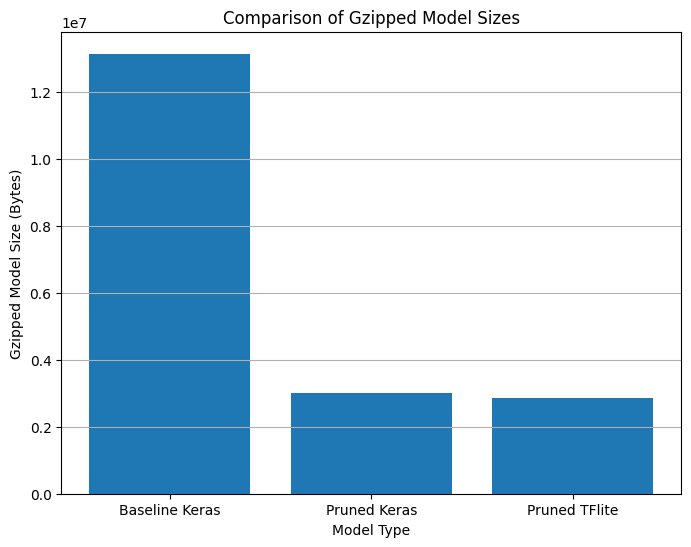

In [15]:
# Calculate the sizes of the gzipped models
keras_size = get_gzipped_model_size(keras_file)
pruned_keras_size = get_gzipped_model_size(pruned_keras_file)
pruned_tflite_size = get_gzipped_model_size(pruned_tflite_file)

# Print the sizes of the gzipped models
print("Size of gzipped baseline Keras model: %.2f bytes" % (keras_size))
print("Size of gzipped pruned Keras model: %.2f bytes" % (pruned_keras_size))
print("Size of gzipped pruned TFlite model: %.2f bytes" % (pruned_tflite_size))

# Model names (adjust labels as needed)
model_names = ["Baseline Keras", "Pruned Keras", "Pruned TFlite"]

# Create a bar chart
plt.figure(figsize=(8, 6))  # Adjust figure size as desired
plt.bar(model_names, [keras_size, pruned_keras_size, pruned_tflite_size])
plt.xlabel("Model Type")
plt.ylabel("Gzipped Model Size (Bytes)")
plt.title("Comparison of Gzipped Model Sizes")

# Display gridlines for better readability
plt.grid(axis='y')

# Display the plot
plt.show()

# Create a 10x smaller model from combining pruning and quantization
When combining quantization with pruning, the model size can be further reduced. Pruning removes unnecessary connections in the model, effectively setting some weights to zero. This reduces the number of non-zero weights in the model. When quantization is applied after pruning, the quantization process can take advantage of the sparsity introduced by pruning. Since many weights are already zero, they can be quantized to zero without any loss of information. This leads to a more compact representation of the model, where both the non-zero weights and the quantized zeros are stored efficiently.

First, we use the TFLiteConverter to convert the pruned Keras model (model_for_export) to a TensorFlow Lite model. We set converter.optimizations to [tf.lite.Optimize.DEFAULT] to enable default optimizations, which include quantization. Next, we convert the model using converter.convert() and save the resulting quantized and pruned TensorFlow Lite model to a temporary file (quantized_and_pruned_tflite_file). We then calculate and print the size of the baseline Keras model (keras_file) and the size of the quantized and pruned TensorFlow Lite model (quantized_and_pruned_tflite_file) using the get_gzipped_model_size function. This allows us to compare the sizes of the two models, demonstrating the reduction in size achieved by combining pruning and quantization.

In [16]:
# Convert the pruned Keras model to a quantized TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
quantized_and_pruned_tflite_model = converter.convert()

# Save the quantized and pruned TensorFlow Lite model to a temporary file
_, quantized_and_pruned_tflite_file = tempfile.mkstemp('.tflite')
with open(quantized_and_pruned_tflite_file, 'wb') as f:
  f.write(quantized_and_pruned_tflite_model)

# Print the path to the saved quantized and pruned TFLite model
print('Saved quantized and pruned TFLite model to:', quantized_and_pruned_tflite_file)

# Calculate and print the sizes of the gzipped models
print("Size of gzipped baseline Keras model: %.2f bytes" % (keras_size))
quantized_and_pruned_tflite_size = get_gzipped_model_size(quantized_and_pruned_tflite_file)
print("Size of gzipped pruned and quantized TFlite model: %.2f bytes" % (quantized_and_pruned_tflite_size))

Summary on the non-converted ops:
---------------------------------
 * Accepted dialects: tfl, builtin, func
 * Non-Converted Ops: 33, Total Ops 95, % non-converted = 34.74 %
 * 33 ARITH ops

- arith.constant:   33 occurrences  (f32: 31, i32: 2)



  (f32: 14)
  (f32: 13)
  (f32: 1)
  (f32: 4)
  (uq_8: 25)
  (f32: 1)
  (f32: 1)


Saved quantized and pruned TFLite model to: /tmp/tmpcaejvtmw.tflite
Size of gzipped baseline Keras model: 13129769.00 bytes
Size of gzipped pruned and quantized TFlite model: 867107.00 bytes


Let's plot all the Gzipped Model Sizes

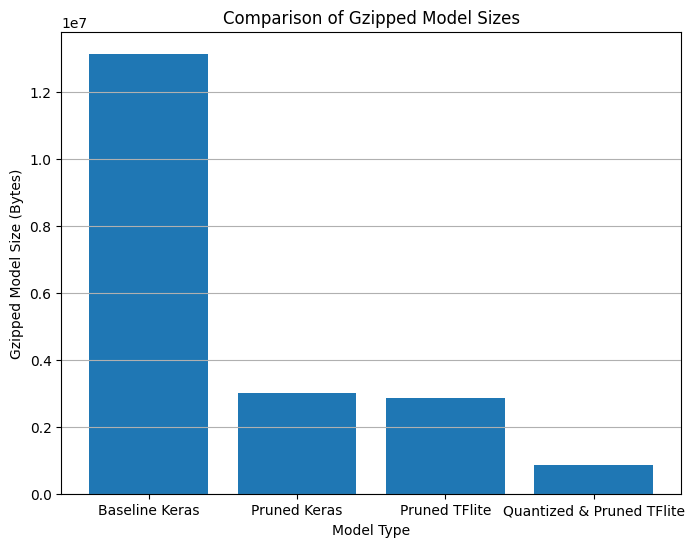

In [17]:
model_names = ["Baseline Keras", "Pruned Keras", "Pruned TFlite", "Quantized & Pruned TFlite"]

plt.figure(figsize=(8, 6)) 
plt.bar(model_names, [keras_size, pruned_keras_size, pruned_tflite_size, quantized_and_pruned_tflite_size])
plt.xlabel("Model Type")
plt.ylabel("Gzipped Model Size (Bytes)")
plt.title("Comparison of Gzipped Model Sizes")
plt.grid(axis='y')
plt.show()

### Accuracy from TF to TFLite
We will be creating a helper function called *evaluate_model_from_generator* that will evaluate the TensorFlow Lite model using a generator that provides batches of images. It iterates over each batch, performs inference on each image using the interpreter, and compares the predicted digits with the ground truth labels to calculate the accuracy of the model.

In [18]:
def evaluate_model_from_generator(interpreter, test_generator, test_labels):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]

    # Run predictions on every batch in the test_generator.
    prediction_digits = []
    num_batches = len(test_generator)
    for i in range(num_batches):
        batch_images, _ = next(test_generator)
        for j in range(len(batch_images)):
            if (i * len(batch_images) + j) % 1000 == 0:
                print('Evaluated on {n} results so far.'.format(n=i * len(batch_images) + j))
            test_image = batch_images[j]
            test_image = np.expand_dims(test_image, axis=0)

            # Set the input tensor
            interpreter.set_tensor(input_index, test_image)

            # Run inference
            interpreter.invoke()

            # Get the output tensor
            output = interpreter.tensor(output_index)
            digit = np.argmax(output()[0])
            prediction_digits.append(digit)

    print('\n')
    # Compare prediction results with ground truth labels to calculate accuracy.
    prediction_digits = np.array(prediction_digits)
    accuracy = (prediction_digits == test_labels).mean()
    return accuracy

In [19]:
# Calculate the accuracy of quantized pruned model
interpreter = tf.lite.Interpreter(model_content=quantized_and_pruned_tflite_model)
interpreter.allocate_tensors()

test_generator.reset()  # Reset the generator to start from the beginning
test_labels = test_generator.classes  # Assuming test_generator is a DirectoryIterator
quantized_and_pruned_tflite_model_accuracy = evaluate_model_from_generator(interpreter, test_generator, test_labels)

print('Pruned and quantized TFLite test_accuracy::', quantized_and_pruned_tflite_model_accuracy)

# Create a TensorFlow Lite interpreter with the pruned and quantized TFLite model
interpreter = tf.lite.Interpreter(model_content=pruned_tflite_model)
interpreter.allocate_tensors()

# Reset the test generator and get the ground truth labels
test_generator.reset()
test_labels = test_generator.classes

# Evaluate the pruned and quantized TFLite model using the interpreter
pruned_tflite_model_accuracy = evaluate_model_from_generator(interpreter, test_generator, test_labels)

# Print the accuracy of the pruned and quantized TFLite model
print('Pruned TFLite test_accuracy:', pruned_tflite_model_accuracy)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Evaluated on 0 results so far.


Pruned and quantized TFLite test_accuracy:: 0.8703703703703703
Evaluated on 0 results so far.


Pruned TFLite test_accuracy: 0.8809523809523809


Let's print and plot the accuracy of basline model, pruned keras, pruned TFlite and pruned TFlite with quantization. 

Baseline test accuracy: 0.8439153432846069
Pruned keras test accuracy: 0.8809523582458496
Pruned and quantized TFLite test accuracy: 0.8703703703703703
Pruned TFLite test accuracy: 0.8809523809523809


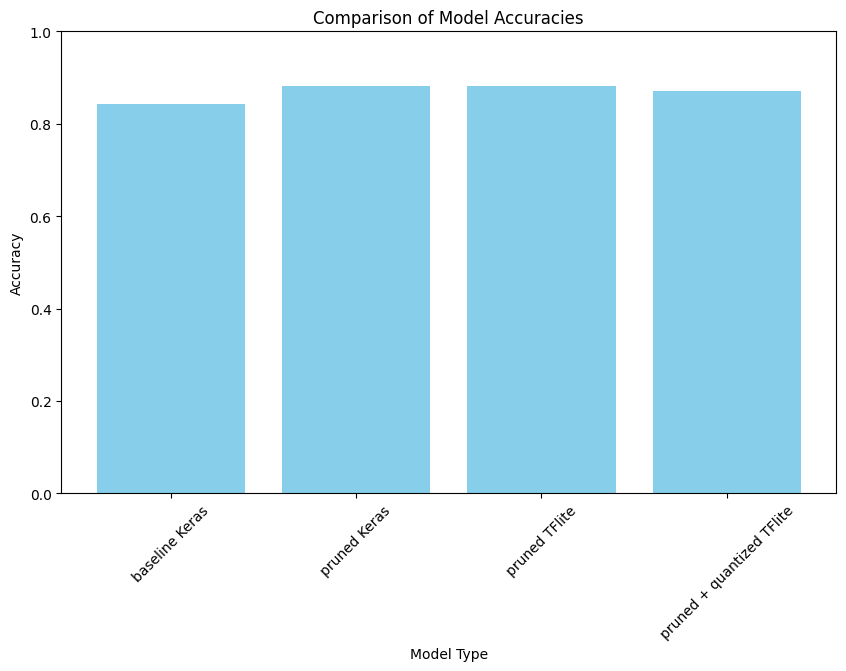

In [20]:
# Print the test accuracies of the different models
print('Baseline test accuracy:', baseline_model_accuracy)
print('Pruned keras test accuracy:', model_for_pruning_accuracy)
print('Pruned and quantized TFLite test accuracy:', quantized_and_pruned_tflite_model_accuracy)
print('Pruned TFLite test accuracy:', pruned_tflite_model_accuracy)

# Define the models and their corresponding accuracies for plotting
models = ['baseline Keras', 'pruned Keras', 'pruned TFlite', 'pruned + quantized TFlite']
accuracies = [baseline_model_accuracy, model_for_pruning_accuracy, pruned_tflite_model_accuracy, quantized_and_pruned_tflite_model_accuracy]

# Plot the accuracies
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color='skyblue')
plt.xlabel('Model Type')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Set y-axis limit to 0-1 for accuracy percentage
plt.show()


Let's apply our model to see the predictions. First we will use the base model and later we will use the pruned with quantized TFlite model.


1/1 [==============================] - 0s 20ms/step


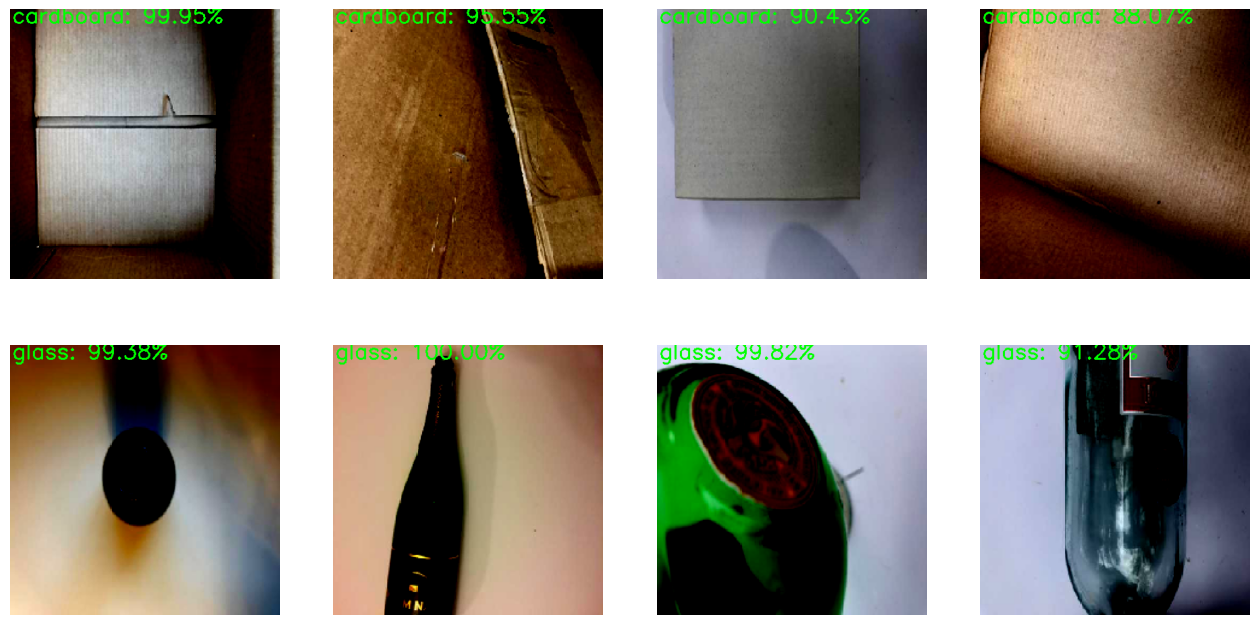

In [21]:
# Parameters for our graph; we'll output images in a 4x4 configuration
nrows = 2
ncols = 4

# Set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)
waste_types = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


# Iterate over batches from the test generator
for i in range(nrows * ncols):
    # Get a batch of images and labels from the test generator
    batch_images, batch_labels = next(test_generator)
    
    # Select the first image from the batch
    image = batch_images[0]
    label = batch_labels[0]
    
    # Predict the label for the image
    preds = model.predict(np.expand_dims(image, axis=0))[0]
    predicted_label_index = np.argmax(preds)
    predicted_label = waste_types[predicted_label_index]

    # Convert image to uint8 and RGB (if needed)
    output = image.copy()
    # Resize the output image
    output = imutils.resize(output, width=400)
    
    # Draw the prediction on the output image
    text = "{}: {:.2f}%".format(predicted_label, preds[predicted_label_index] * 100)
    cv2.putText(output, text, (3, 20), cv2.FONT_HERSHEY_SIMPLEX, 1.05, (0, 255, 0), 2)

    # Show the output image
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(output)
    plt.axis('off')

plt.show()

1/1 [==============================] - 0s 28ms/step


(-0.5, 223.5, 223.5, -0.5)

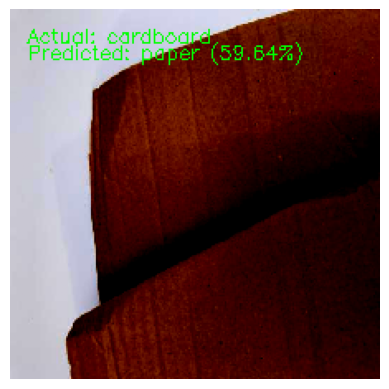

In [22]:
test_generator.reset()

batch = next(test_generator)
images, labels = batch

# Select a random image index
random_index = np.random.randint(0, len(images))

# Get the random image and label
random_image = images[random_index]
random_label = labels[random_index]

# Reshape the image to match the model's input shape
input_image = np.expand_dims(random_image, axis=0)

# Use the model to predict the label
prediction = model.predict(input_image)

# Define the class names
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# Get the predicted label index and class name
predicted_label_index = np.argmax(prediction)
predicted_class_name = class_names[predicted_label_index]
actual_class_name = class_names[int(random_label)]

# Display the random image with text
output = random_image.copy()
text_actual = "Actual: {}".format(actual_class_name)
text_predicted = "Predicted: {} ({:.2f}%)".format(predicted_class_name, prediction[0][predicted_label_index] * 100)
cv2.putText(output, text_actual, (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
cv2.putText(output, text_predicted, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)


# Show the image
plt.imshow(output)
plt.axis('off')

Let's save the pruned and quantized model in output for mobile usage.

In [23]:
# Define the output folder and filename for the quantized and pruned model
output_folder = '/kaggle/working/'
output_filename = 'quantized_and_pruned_model.tflite'
output_path = os.path.join(output_folder, output_filename)

# Write the quantized and pruned TensorFlow Lite model to a file
with open(output_path, 'wb') as f:
    f.write(quantized_and_pruned_tflite_model)

# Print the path where the model is saved
print(f"Quantized and pruned model saved to: {output_path}")

Quantized and pruned model saved to: /kaggle/working/quantized_and_pruned_model.tflite


# Conclusion
In this example, we have learned how to use the TensorFlow Model Optimization Toolkit API for both TensorFlow and TensorFlow Lite. We have explored the process of creating sparse models by combining pruning with post-training quantization, which results in smaller model sizes and reduced computational requirements. We have also demonstrated the effectiveness of these techniques by creating a 10x smaller model for the TrashNet dataset with minimal accuracy difference compared to the original model.

Pruning and quantization are powerful techniques that can optimize deep learning models, especially in resource-constrained environments. They help to reduce model size and computational requirements while maintaining similar performance to the original model.